# Small (LEVIATHAN)
Here, we visualize the inversions that were identified for the `small` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 90 -m 90 -l 90`.

In [1]:
library(ggplot2)
library(dplyr)
library(ggpubr)
.size <- "small"


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




These are the setup functions that process that data.

In [2]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    samplesfile <- paste("../../simulated_data/visor/called_sv/leviathan", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("../../simulated_data/visor/called_sv/leviathan", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]
    sample_inversions$sample <- as.integer(gsub("sample_", "", sample_inversions$sample))
    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- 11L
    }
    outdf <- rbind(sample_inversions, pooled_inversions)
    outdf$depth <- depth
    return(outdf)
}

read_candidatefile <- function(.size, .depth, .sample) {
    if (.sample <= 10){
        .cand_file <- sprintf("../../simulated_data/visor/called_sv/leviathan/%s/depth_%s/by_sample/logs/leviathan/sample_%02d.candidates", .size, .depth, .sample)
    } else {
        .cand_file <- sprintf("../../simulated_data/visor/called_sv/leviathan/%s/depth_%s/by_pop/logs/leviathan/pop1.candidates", .size, .depth)
    }
    .x <- read.table(
        .cand_file,
        col.names = c("contig", "position_start", "position_end", "contig2", "position_start2", "position_end2", "barcodes")
    )
    .x$sample <- .sample
    .x$depth <- .depth
    return (.x)
}

read_all_data <- function(size_treatment){
    .data <- read_data(size_treatment, 0.5)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(.size, i))    
    }
    return(.data)
}

Read in all the leviathan candidates for this size inversion

In [3]:
# read in once to create properly formatted (but empty) table
candidates <- read_candidatefile(.size, 0.5, 1)[0,]

for (i in c(0.5, 2, 5, 10, 20)) {
    .depthcand <- Reduce(
        rbind,
        Map(function(x){read_candidatefile(.size, i, x)}, 1:11)
    )
    candidates <- rbind(candidates, .depthcand)
}

head(candidates)

,contig,position_start,position_end,contig2,position_start2,position_end2,barcodes,sample,depth
,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>
1,2L,22568000,22568999,2L,22567000,22567999,4,1,0.5
2,2R,19406000,19406999,2R,19405000,19405999,4,1,0.5
3,2L,3021000,3021999,2L,3014000,3014999,3,1,0.5
4,3R,16434000,16434999,3R,16429000,16429999,3,1,0.5
5,3L,15140000,15140999,3L,15159000,15159999,3,1,0.5
6,2L,22036000,22036999,2L,22031000,22031999,3,1,0.5


In [4]:
samplesSV <- read_all_data(.size)
head(samplesSV)

,sample,contig,position_start,position_end,depth
,<int>,<chr>,<int>,<int>,<dbl>
1,8,2L,3193195,3214221,0.5
2,1,2L,3940210,3944864,0.5
3,9,3R,20081036,20093595,0.5
4,6,3L,4085867,4090819,0.5
5,11,2L,3193195,3214221,0.5
6,11,2L,3940210,3944864,0.5


Read in the sample and pool simulation inventory, add the `assessment` and `candidate` columns

In [5]:
performance <- read.table("inversion.assessment", header = T)
performance <- performance[performance$size == .size,]
performance$assessment <- ifelse(performance$simulated, "false negative", "true negative")
performance$candidate <- F
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,candidate
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<lgl>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
3,2L,1,1,5.0,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
4,2L,1,1,10.0,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
5,2L,1,1,20.0,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,FALSE


### Assess the performance of identified inversions

In [6]:
near_breakpoint <- function(x, y, tolerance = 75){
    # x is the simulated/known breakpoints
    # y is the breakpoint we want to compare
    # check if y is within tolerance of x
    return(
        (y >= x - tolerance) & (y <= x + tolerance)
    )
}

In [7]:
false_positives <- samplesSV[0,]

for(i in 1:nrow(samplesSV)){
    .row <- samplesSV[i,]
    query <- which(
        performance$sample == .row$sample &
        performance$depth == .row$depth &
        performance$contig == .row$contig &
        near_breakpoint(performance$position_start, .row$position_start, 100) &
        near_breakpoint(performance$position_end, .row$position_end, 100)
    )
    if(length(query) > 0) {
        if (performance$simulated[query]){
            performance$assessment[query] <- "true positive"
        } else {
            performance$assessment[query] <- "false positive"
            false_positives <- rbind(false_positives, .row)
        }
    } # false negative otherwise
}
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,candidate
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<lgl>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,FALSE
3,2L,1,1,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE
4,2L,1,1,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE
5,2L,1,1,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,FALSE


Were `false negatives` ever initially detected in the candidates? In other words, did the first part of LEVIATHAN identify a potential inversion but filter it out after?

In [8]:
for(i in 1:nrow(performance)){
    if (performance$assessment[i] == "false negative"){
        # check if it's in the candidates
        .row <- performance[i,]
        query <- which(
            candidates$sample == .row$sample[1] &
            candidates$contig == .row$contig[1] &
            (.row$position_start[1]  > candidates$position_start & .row$position_start < candidates$position_end) &
            (.row$position_end[1]  > candidates$position_start2 & .row$position_end < candidates$position_end2)
        )
        if (length(query) > 0){
            performance$candidate[i] <- TRUE
        }
    }
}
head(performance[performance$candidate & performance$assessment == "false negative",])

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,candidate
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<lgl>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,TRUE
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,TRUE
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,TRUE
7,2L,1,1,2.0,2,small,TRUE,homozygous,3193196,3214221,false negative,TRUE
11,2L,1,1,0.5,3,small,TRUE,homozygous,3193196,3214221,false negative,TRUE
16,2L,1,1,0.5,4,small,TRUE,homozygous,3193196,3214221,false negative,TRUE


Create a column that looks for "not called but was a candidate"

In [9]:
performance$assess_cand <- gsub("false negative", "false negative (undetected)", performance$assessment)
performance$assess_cand[performance$assess_cand == "false negative (undetected)" & performance$candidate] <- "false negative (filtered)"
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,candidate,assess_cand
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,TRUE,false negative (filtered)
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,TRUE,false negative (filtered)
3,2L,1,1,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE,true positive
4,2L,1,1,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE,true positive
5,2L,1,1,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,FALSE,true positive
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,TRUE,false negative (filtered)


Are there false positives?

In [10]:
head(false_positives)
if (nrow(false_positives) > 0) {
    false_positives$size <- .size
    false_positives$method <- "leviathan"
    write.table(false_positives, file = paste0("false_positives.", .size), row.names = F, quote = F)
}

sample,contig,position_start,position_end,depth
<int>,<chr>,<int>,<int>,<dbl>


Augment the table to capture all the inversions that were simulated (groundtruth for plotting purposes)

In [11]:
truth <- filter(performance, simulated) %>%
    select(contig, inversion, position_start, position_end) |> unique() %>%
    mutate(assessment = "true positive", sample = 0, depth = 20)

head(truth)

,contig,inversion,position_start,position_end,assessment,sample,depth
,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
1,2L,1,3193196,3214221,true positive,0,20
56,2L,2,3940211,3944863,true positive,0,20
111,2L,3,13024404,13026577,true positive,0,20
166,2L,4,14845709,14861200,true positive,0,20
221,2L,5,20107901,20113695,true positive,0,20
276,2R,1,4328632,4333509,true positive,0,20


### Single-Sample Detection
Let's first visualize what detection looked like across the genome. Here, we facet across contigs and show all the depths at once. Since the small inversions are indeed quite small, for visualization purposes, we'll make each of them 100 kb bigger.

In [12]:
plot_inversions <- function(data, groundtruth, size_treatment){
    options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
    .tbl <- filter(data, assessment == "true positive") %>% select(contig, inversion, position_start, position_end, depth, assessment, sample)
    
    rbind(.tbl, groundtruth) %>%

    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end+100000,
            color = as.factor(depth),
        )
    ) +
        geom_linerange(position = position_dodge(0.7), linewidth = 1.5) +
        coord_flip() +
        scale_color_brewer(name = "sequencing depth", palette = "Set2") +
        scale_x_continuous(breaks = 0:11,limits = c(0, 11)) +
        scale_y_continuous(labels = scales::comma) +
        theme_light() +
        theme(
            panel.grid.major.y = element_blank(),
            legend.position = "top",
            panel.grid.minor.y = element_line(color = "gray80", size = 0.5)
        ) +
        labs(
            title = "Simulated and Called Inversions Across the Genome",
            subtitle = paste0("Size: ", size_treatment),
            y = "genomic position (bp)",
            caption = "sample 0 = groundtruth | sample 11 = pooled"
        ) + 
        facet_grid(cols = vars(contig))
}

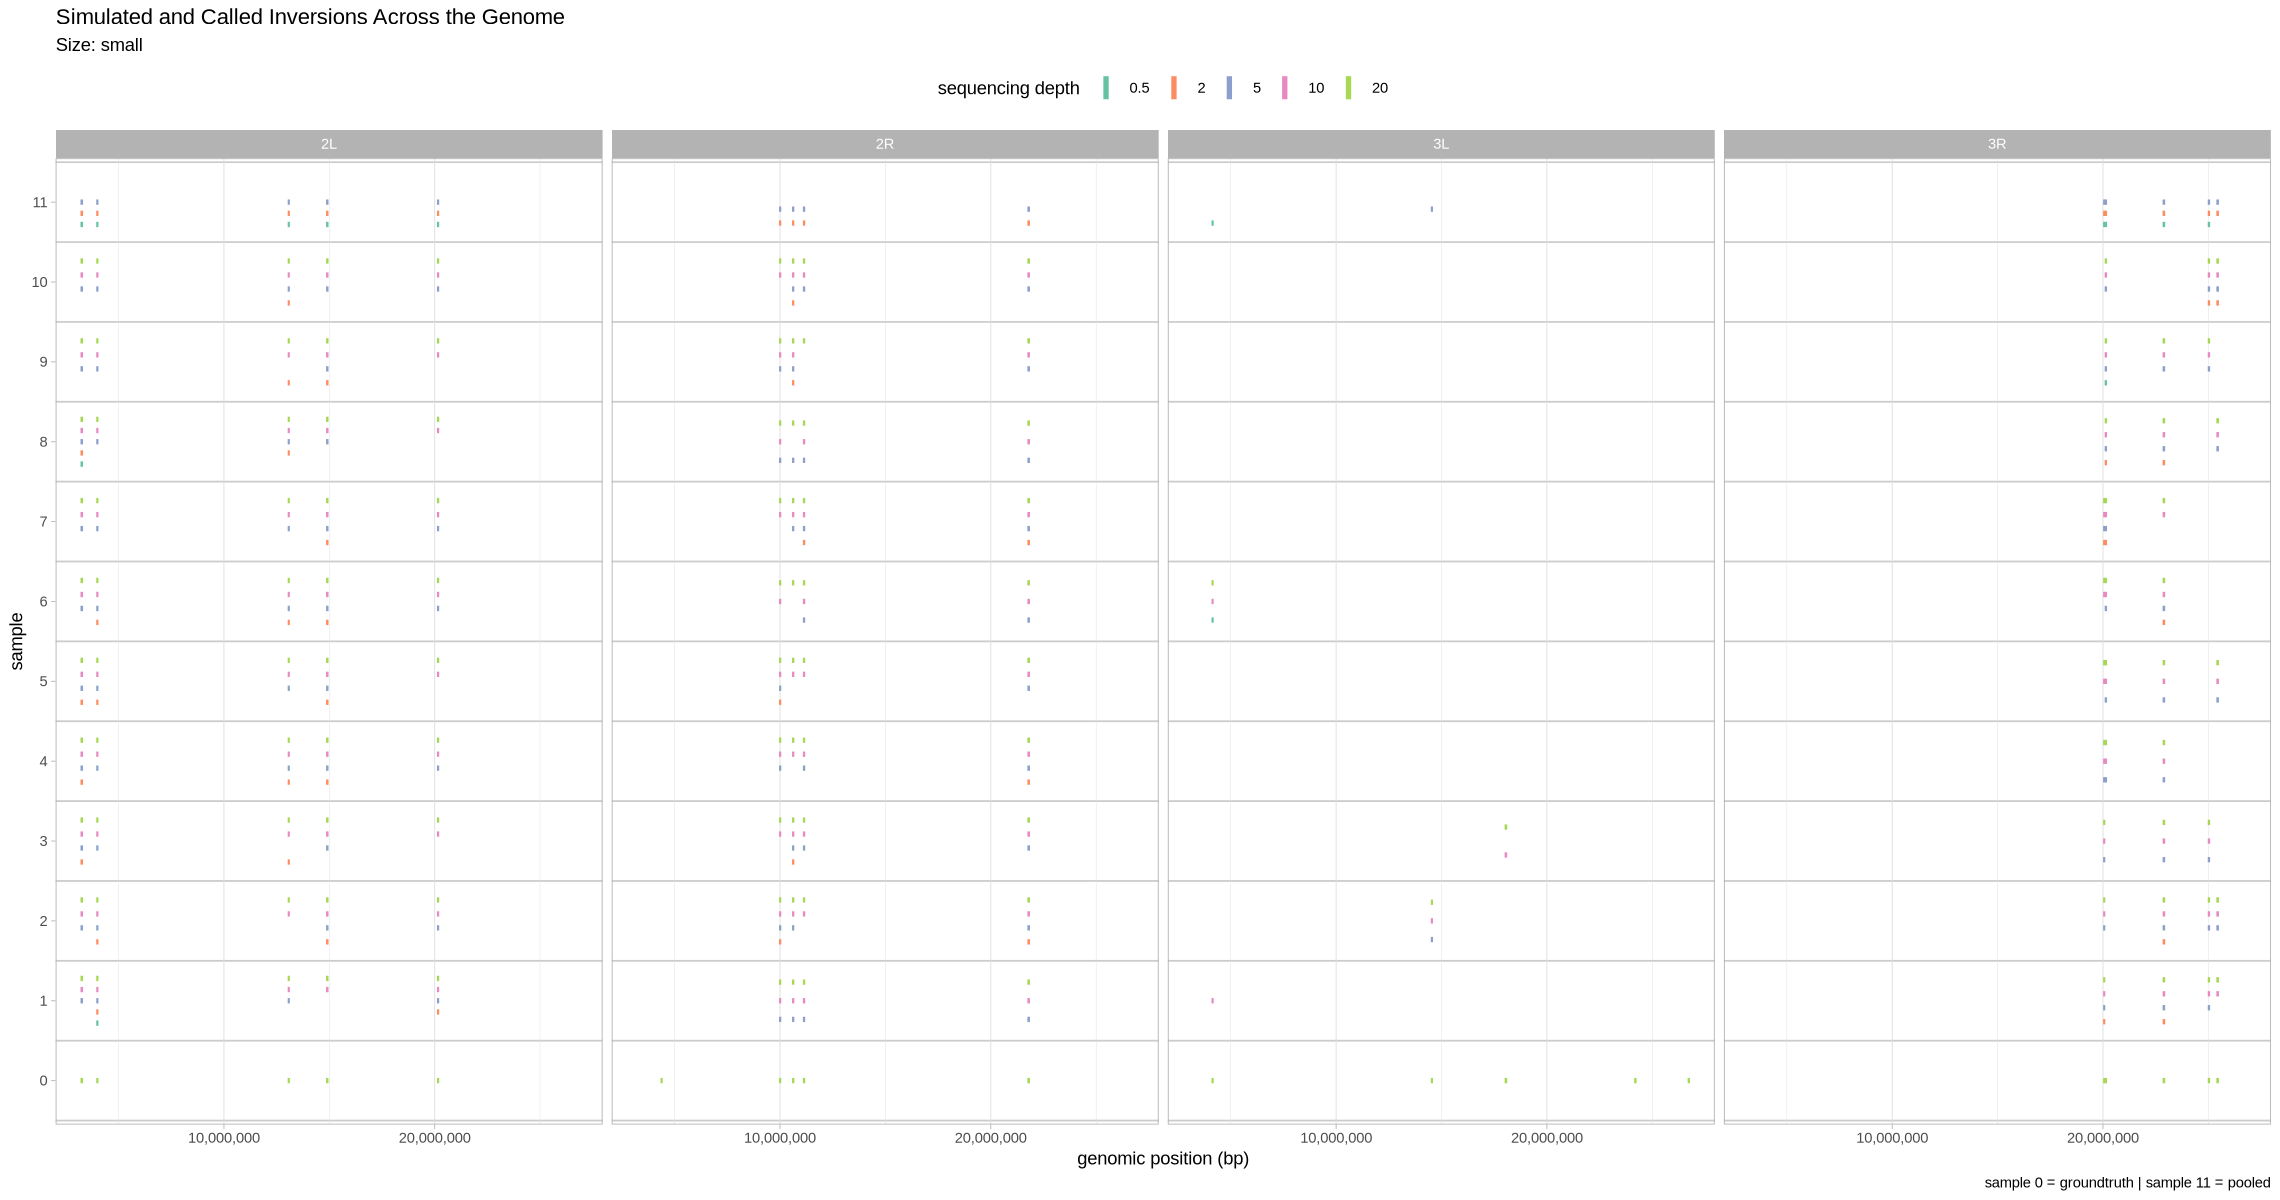

In [13]:
plot_inversions(performance, truth, .size)

What does this look like as a heatmap of true/false positive/negative?

In [ ]:
plot_samples_scattermatrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 10, repr.plot.height = 15)
    .data <- data[data$sample != 11,]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = inversion, color = assess_cand, fill = assess_cand, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = paste(size_treatment, "inversions detected in individual samples, as a function of zygotic state.")) +
        scale_color_manual(name = "Assessment", values = c("false negative (undetected)" = "grey75", "false negative (filtered)" = "indianred", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative (undetected)" = "white", "false negative (filtered)" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(name = "Zygosity", values = c("homozygous" = 21, "heterozygous" = 22)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

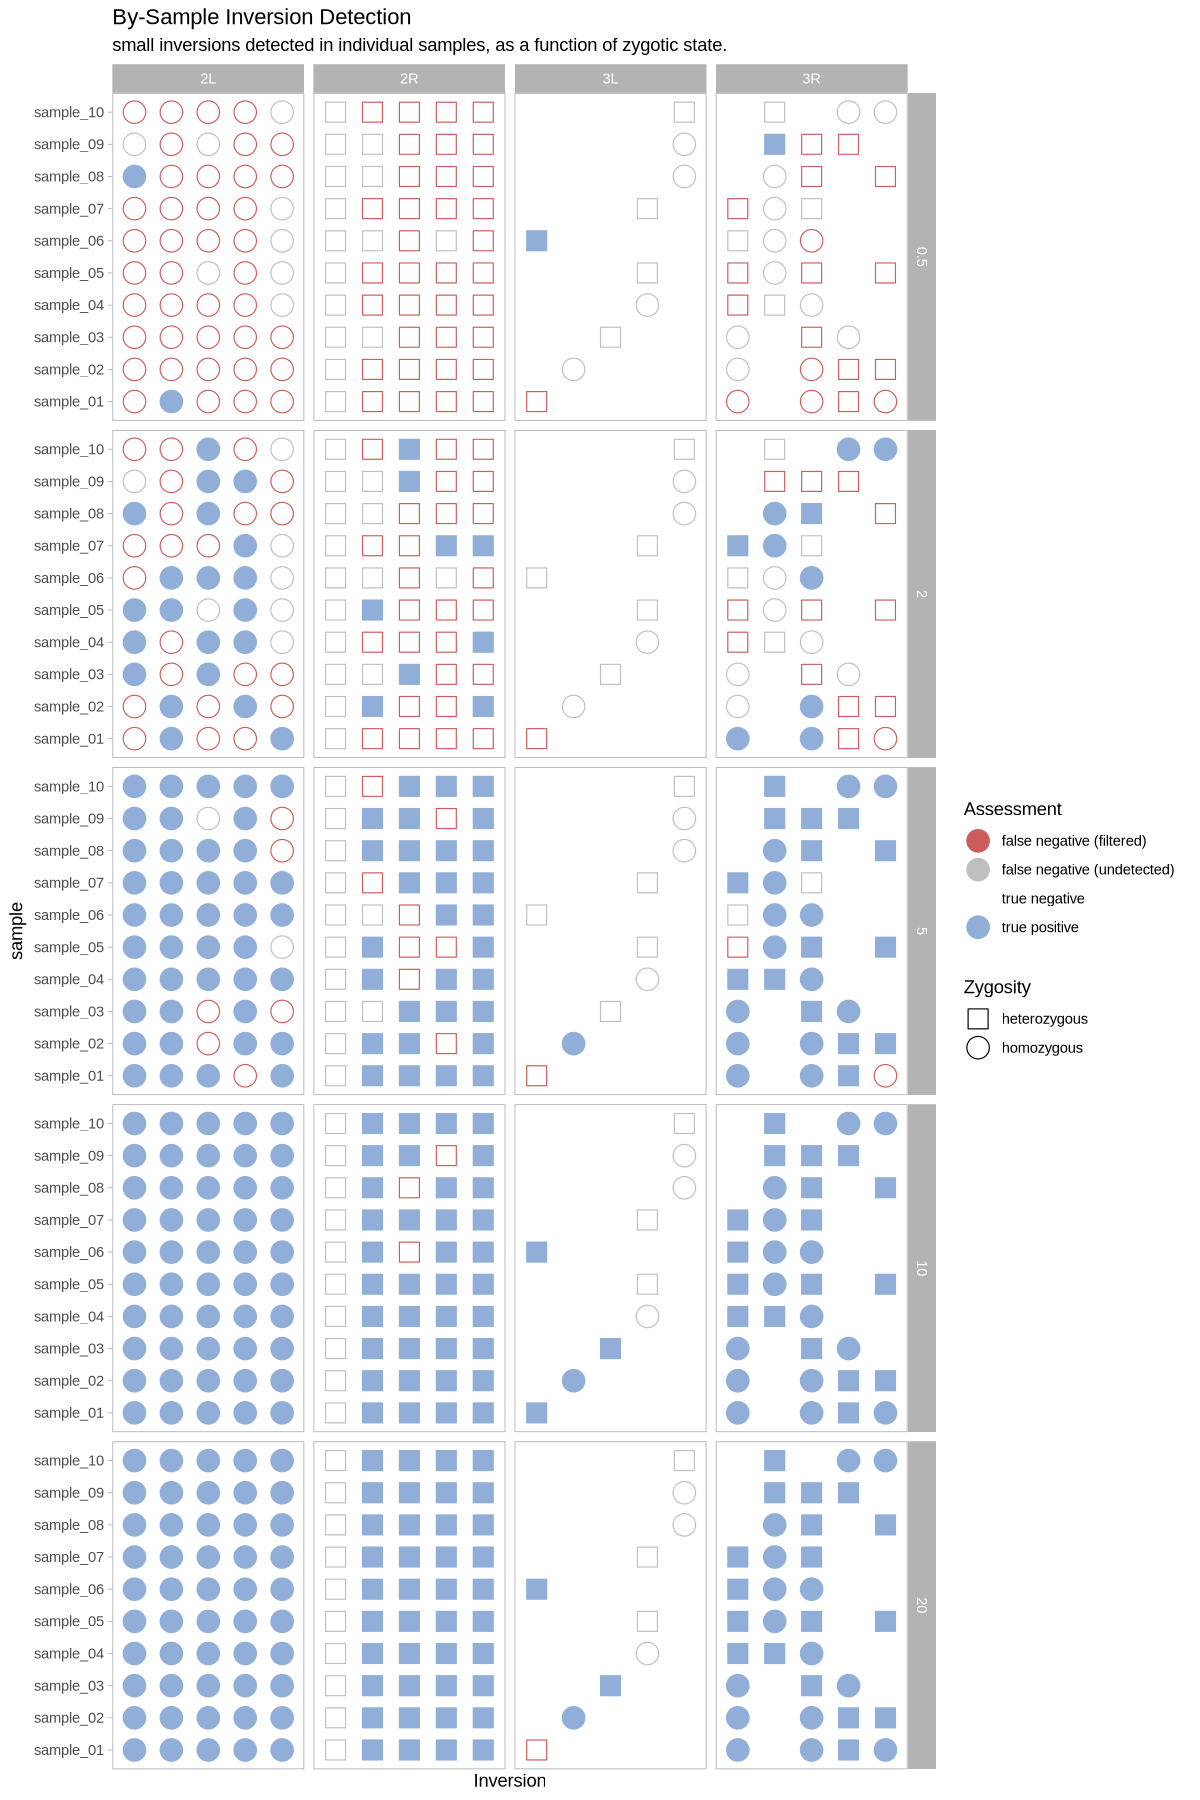

In [15]:
plot_samples_scattermatrix(performance, .size)

### Pooled Sample Detection 

In [16]:
plot_pools_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 14, repr.plot.height = 5)
    .data <- data[data$sample == 11,]
    .data$contig <- gsub("2L", "hom", .data$contig)
    .data$contig <- gsub("2R", "het", .data$contig)
    .data$contig <- gsub("3L", "rare", .data$contig)
    .data$contig <- gsub("3R", "common", .data$contig)
    .data$contig <- factor(.data$contig,levels = c("hom","het","common", "rare"), ordered = T)

    ggplot(.data, aes(y = 1, x = inversion, color = assess_cand, fill = assess_cand)) +
        geom_point(size = 16, shape = 22) +
        theme_light() +
        labs(title = "Pooled-Sample Detection", subtitle = paste(size_treatment, "inversions detected in sample-pooled data, as a function of inversion frequency in the population.")) +
        scale_color_manual(name = "Assessment", values = c("false negative (undetected)" = "grey75", "false negative (filtered)" = "indianred", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative (undetected)" = "white", "false negative (filtered)" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

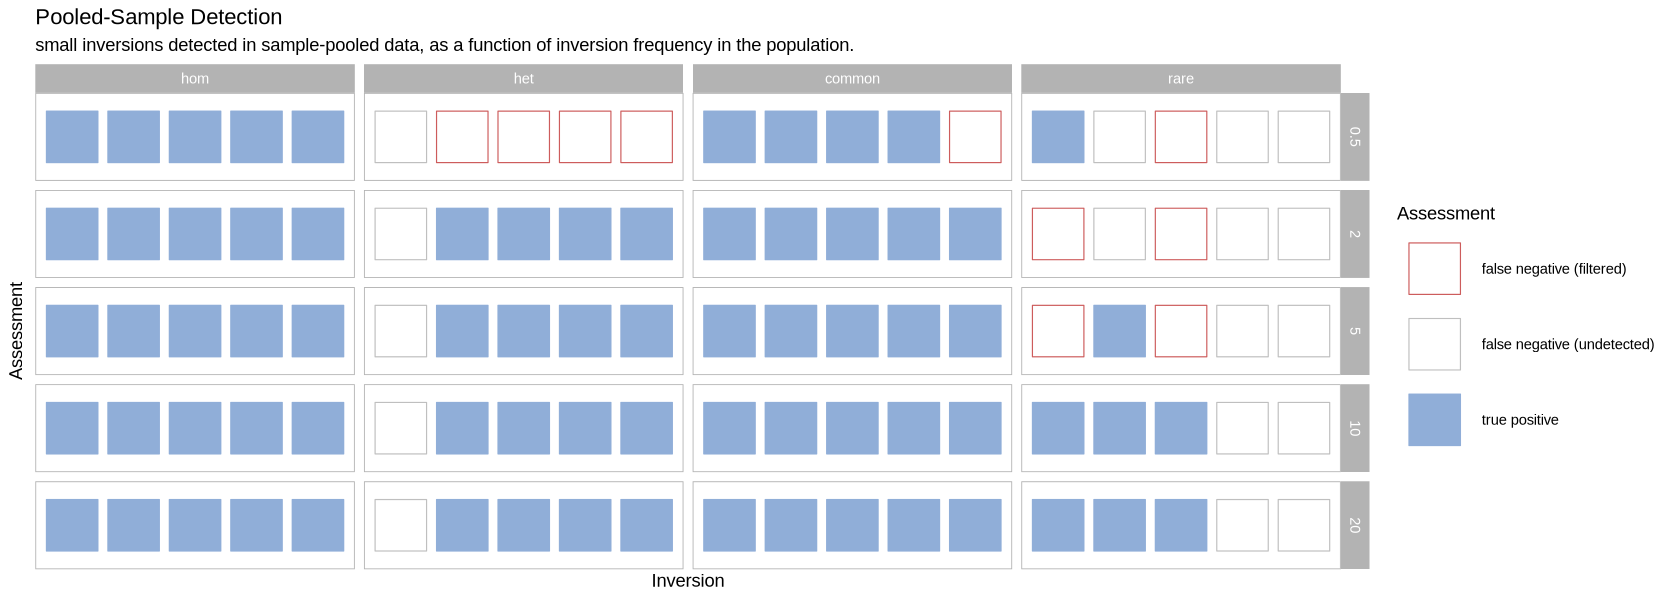

In [17]:
plot_pools_matrix(performance, .size)

Write this all to a file to tease apart later

In [18]:
write.csv(performance, file = paste0(.size, ".sv.assessment"), quote = F, row.names = F)